In [3]:
#Data Cleaning
import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving titanic.xlsx to titanic.xlsx


In [6]:
#Load and Inspect the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
df = pd.read_excel("titanic.xlsx")

# Initial inspection
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData types and non-null counts:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())


Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [7]:
#Identify and Remove Duplicates
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate PassengerId:", df['PassengerId'].duplicated().sum())

df = df.drop_duplicates()
print("After removing duplicates:", len(df))

Total rows: 891
Duplicate rows: 0
Duplicate PassengerId: 0
After removing duplicates: 891


In [8]:
#Remove Irrelevant Columns
# These columns won't help with prediction
print("Columns before dropping:", df.shape)
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print("Columns after dropping irrelevant ones:", df.shape)
print("Remaining columns:", df.columns.tolist())

Columns before dropping: (891, 12)
Columns after dropping irrelevant ones: (891, 8)
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [9]:
#Missing Values Handling
# Check missing values in detail
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
print(missing_data)
print('\n')
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Data Summary:")
print(missing_data)

            Column  Missing_Count  Missing_Percent
Survived  Survived              0         0.000000
Pclass      Pclass              0         0.000000
Sex            Sex              0         0.000000
Age            Age            177        19.865320
SibSp        SibSp              0         0.000000
Parch        Parch              0         0.000000
Fare          Fare              0         0.000000
Embarked  Embarked              2         0.224467


Missing Data Summary:
            Column  Missing_Count  Missing_Percent
Age            Age            177        19.865320
Embarked  Embarked              2         0.224467


In [10]:
#Handling Missing 'Age'

print("Age statistics by Passenger Class:")
print(df.groupby('Pclass')['Age'].describe())

# Filling missing ages with median age for each class
for pclass in df['Pclass'].unique():
    median_age = df[df['Pclass'] == pclass]['Age'].median()
    df.loc[(df['Pclass'] == pclass) & (df['Age'].isnull()), 'Age'] = median_age

print("\nAfter filling Age:")
print("Missing Age values:", df['Age'].isnull().sum())
print("Age distribution after imputation:")
print(df['Age'].describe())

Age statistics by Passenger Class:
        count       mean        std   min   25%   50%   75%   max
Pclass                                                           
1       186.0  38.233441  14.802856  0.92  27.0  37.0  49.0  80.0
2       173.0  29.877630  14.001077  0.67  23.0  29.0  36.0  70.0
3       355.0  25.140620  12.495398  0.42  18.0  24.0  32.0  74.0

After filling Age:
Missing Age values: 0
Age distribution after imputation:
count    891.000000
mean      29.066409
std       13.244532
min        0.420000
25%       22.000000
50%       26.000000
75%       37.000000
max       80.000000
Name: Age, dtype: float64


In [12]:
#Handling Missing 'Fare' and 'Embarked'

print("Fare statistics:")
print(df['Fare'].describe())

df['Fare'].fillna(df['Fare'].median(), inplace=True)
print("Missing Fare after imputation:", df['Fare'].isnull().sum())

print("\nEmbarked distribution:")
print(df['Embarked'].value_counts())

df['Embarked'].fillna(df['Embarked'].mode(), inplace=True)
print("Missing Embarked after imputation:", df['Embarked'].isnull().sum())

print("\nTotal missing values in dataset:")
print(df.isnull().sum())

Fare statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
Missing Fare after imputation: 0

Embarked distribution:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Missing Embarked after imputation: 2

Total missing values in dataset:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


In [15]:
## Detecting Outliers Using IQR Method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("Number of Fare outliers:", len(outliers))

Number of Fare outliers: 116


In [17]:
#Exploratory Data Analysis
#Descriptive Statistics
print("Dataset Statistics After Cleaning:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())


Dataset Statistics After Cleaning:
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.066409    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.244532    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   26.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   37.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

Data Types:
Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries

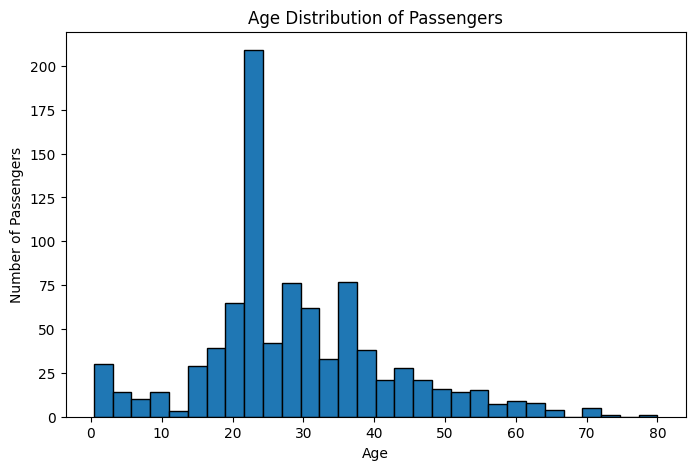

In [18]:
#Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30, edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

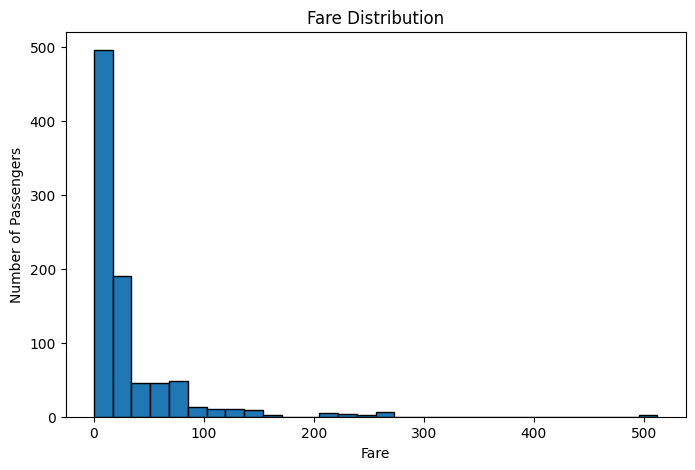

In [19]:
#Fare Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Fare'], bins=30, edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()

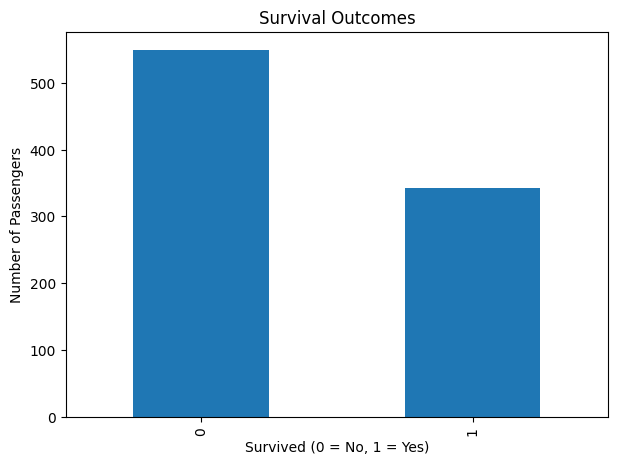

In [20]:
#Survival Distribution
plt.figure(figsize=(7,5))
df['Survived'].value_counts().sort_index().plot(kind='bar')
plt.title('Survival Outcomes')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

In [22]:
# Analyze how features relate to survival
print("Survival Rate by Feature:")
print("="*50)

# By Pclass
print("\nBy Passenger Class:")
print(df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean']))

# By Sex
print("\nBy Sex (0=Male, 1=Female):")
print(df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean']))

# By Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100],
                         labels=['Child', 'Teen', 'Adult', 'Senior'])
print("\nBy Age Group:")
print(df.groupby('Age_Group')['Survived'].agg(['sum', 'count', 'mean']))

Survival Rate by Feature:

By Passenger Class:
        sum  count      mean
Pclass                      
1       136    216  0.629630
2        87    184  0.472826
3       119    491  0.242363

By Sex (0=Male, 1=Female):
        sum  count      mean
Sex                         
female  233    314  0.742038
male    109    577  0.188908

By Age Group:
           sum  count      mean
Age_Group                      
Child       40     69  0.579710
Teen        30     70  0.428571
Adult      271    744  0.364247
Senior       1      8  0.125000


Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.047255
Pclass     -0.338481
Name: Survived, dtype: float64


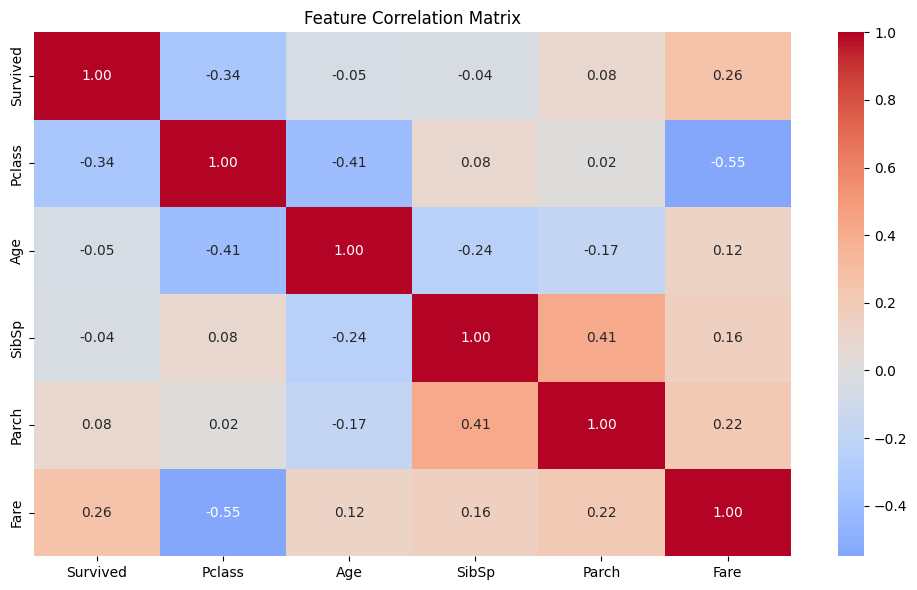

In [24]:
# Correlation with target (Survived)
correlation_with_target = df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
print("Correlation with Survival:")
print(correlation_with_target)

# Visualization
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()